In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 5)

In [2]:
train_txn = pd.read_csv('../data/raw/train_transaction.csv')
train_id  = pd.read_csv('../data/raw/train_identity.csv')

In [3]:
print(f"Train Transaction : {train_txn.shape}")
print(f"Train Identity    : {train_id.shape}")

Train Transaction : (590540, 394)
Train Identity    : (144233, 41)


In [4]:
train_txn.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
train_id.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [6]:
df = train_txn.merge(train_id, on='TransactionID', how='left')
print(f"Merged DataFrame  : {df.shape}")

Merged DataFrame  : (590540, 434)


In [7]:
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [8]:
print(df.dtypes.value_counts())

float64    399
object      31
int64        4
Name: count, dtype: int64


In [9]:
print(df[['TransactionID', 'TransactionDT', 'TransactionAmt',
          'ProductCD', 'card4', 'isFraud']].head())

   TransactionID  TransactionDT  TransactionAmt ProductCD       card4  isFraud
0        2987000          86400            68.5         W    discover        0
1        2987001          86401            29.0         W  mastercard        0
2        2987002          86469            59.0         W        visa        0
3        2987003          86499            50.0         W  mastercard        0
4        2987004          86506            50.0         H  mastercard        0


In [13]:
fraud_counts = df['isFraud'].value_counts()
fraud_pct = df['isFraud'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Count': fraud_counts, 'Percentage': fraud_pct.round(2)}))

          Count  Percentage
isFraud                    
0        569877        96.5
1         20663         3.5


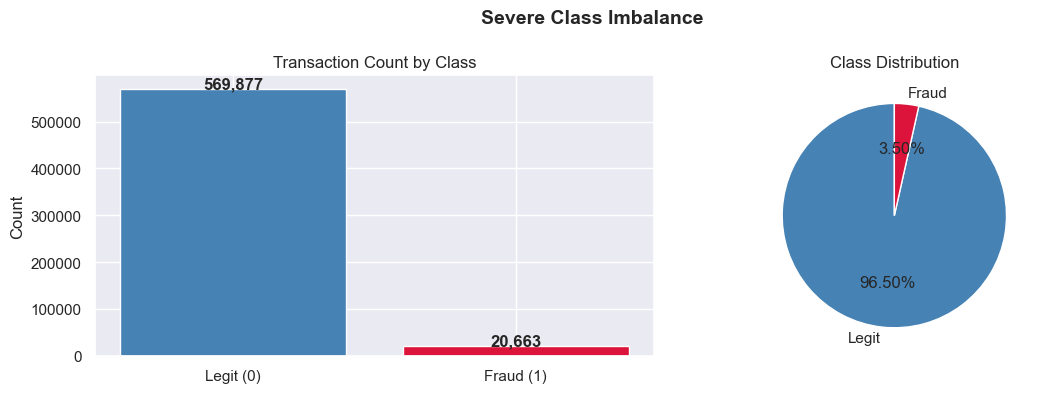

Saved: 01_class_imbalance.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Legit (0)', 'Fraud (1)'],
            fraud_counts.values,
            color=['steelblue', 'crimson'])
axes[0].set_title('Transaction Count by Class')
axes[0].set_ylabel('Count')

for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(fraud_counts.values,
            labels=['Legit', 'Fraud'],
            autopct='%1.2f%%',
            colors=['steelblue', 'crimson'],
            startangle=90)
axes[1].set_title('Class Distribution')

plt.suptitle('Severe Class Imbalance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/01_class_imbalance.png', dpi=150)
plt.show()
print("Saved: 01_class_imbalance.png")

In [22]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)


print(f"Total columns     : {df.shape[1]}")
print(f"Cols with missing : {len(missing_df)}")
print(f"\nTop 20 columns with most missing:")
print(missing_df.head(20))

Total columns     : 434
Cols with missing : 414

Top 20 columns with most missing:
       Missing Count  Missing %
id_24         585793      99.20
id_07         585385      99.13
id_25         585408      99.13
id_08         585385      99.13
id_26         585377      99.13
id_21         585381      99.13
id_23         585371      99.12
id_22         585371      99.12
id_27         585371      99.12
dist2         552913      93.63
D7            551623      93.41
id_18         545427      92.36
D13           528588      89.51
D14           528353      89.47
D12           525823      89.04
id_04         524216      88.77
id_03         524216      88.77
D6            517353      87.61
id_33         517251      87.59
id_10         515614      87.31


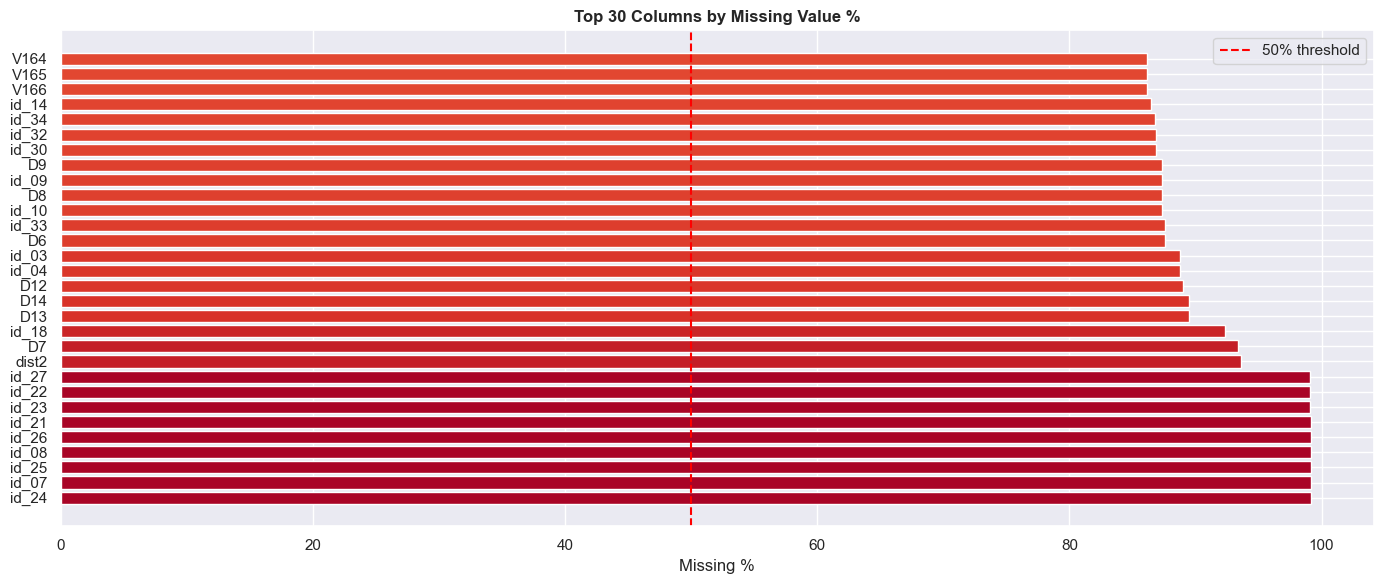

Saved: 02_missing_values.png


In [20]:
fig, ax = plt.subplots(figsize=(14, 6))
top_missing = missing_df.head(30)
bars = ax.barh(top_missing.index, top_missing['Missing %'],
               color=plt.cm.RdYlGn_r(top_missing['Missing %'] / 100))
ax.set_xlabel('Missing %')
ax.set_title('Top 30 Columns by Missing Value %', fontweight='bold')
ax.axvline(x=50, color='red', linestyle='--', label='50% threshold')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/02_missing_values.png', dpi=150)
plt.show()
print("Saved: 02_missing_values.png")

In [23]:
print("\n--- Missing % Buckets ---")
print(f"0-25%  missing : {len(missing_df[missing_df['Missing %'] <= 25])} cols")
print(f"25-50% missing : {len(missing_df[(missing_df['Missing %'] > 25) & (missing_df['Missing %'] <= 50)])} cols")
print(f"50-75% missing : {len(missing_df[(missing_df['Missing %'] > 50) & (missing_df['Missing %'] <= 75)])} cols")
print(f"75%+   missing : {len(missing_df[missing_df['Missing %'] > 75])} cols")


--- Missing % Buckets ---
0-25%  missing : 162 cols
25-50% missing : 38 cols
50-75% missing : 6 cols
75%+   missing : 208 cols


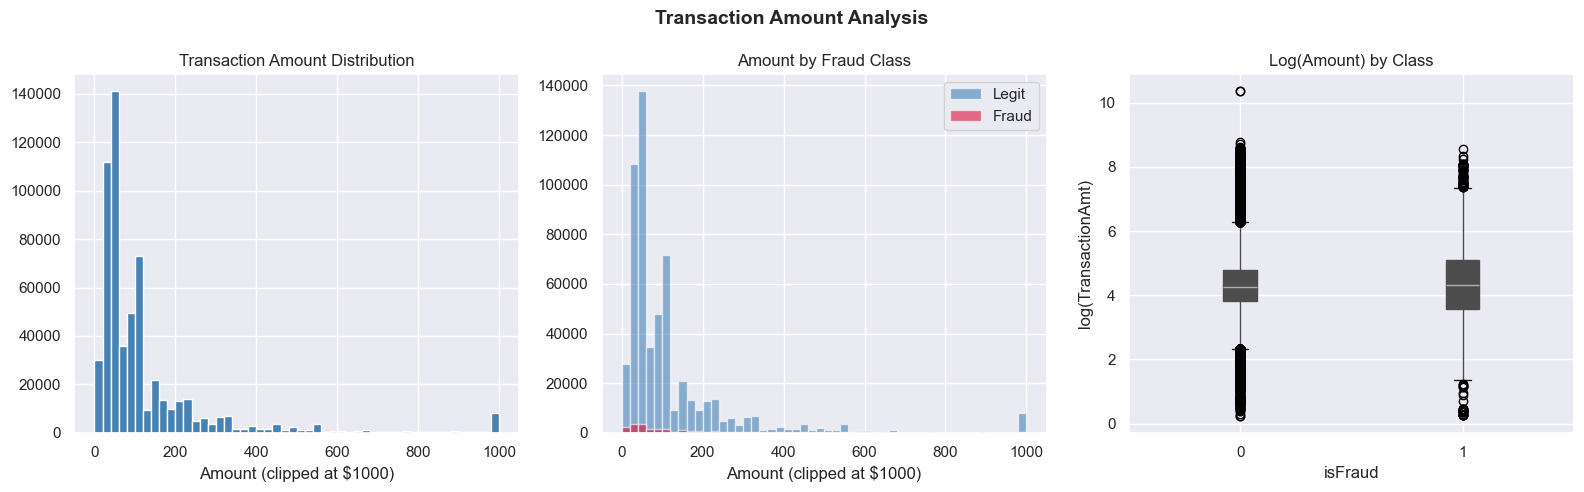


--- Amount Stats by Class ---
            count    mean     std   min    25%   50%    75%       max
isFraud                                                              
0        569877.0  134.51  239.40  0.25  43.97  68.5  120.0  31937.39
1         20663.0  149.24  232.21  0.29  35.04  75.0  161.0   5191.00


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribution overall
axes[0].hist(df['TransactionAmt'].clip(upper=1000), bins=50,
             color='steelblue', edgecolor='white')
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount (clipped at $1000)')

# By fraud class
for label, color in [(0, 'steelblue'), (1, 'crimson')]:
    subset = df[df['isFraud'] == label]['TransactionAmt'].clip(upper=1000)
    axes[1].hist(subset, bins=50, alpha=0.6, color=color,
                 label='Fraud' if label == 1 else 'Legit', edgecolor='white')
axes[1].set_title('Amount by Fraud Class')
axes[1].set_xlabel('Amount (clipped at $1000)')
axes[1].legend()

# Log scale box plot
df['log_amount'] = np.log1p(df['TransactionAmt'])
df.boxplot(column='log_amount', by='isFraud', ax=axes[2],
           patch_artist=True)
axes[2].set_title('Log(Amount) by Class')
axes[2].set_xlabel('isFraud')
axes[2].set_ylabel('log(TransactionAmt)')
plt.suptitle('')

plt.suptitle('Transaction Amount Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/03_transaction_amount.png', dpi=150)
plt.show()

print("\n--- Amount Stats by Class ---")
print(df.groupby('isFraud')['TransactionAmt'].describe().round(2))

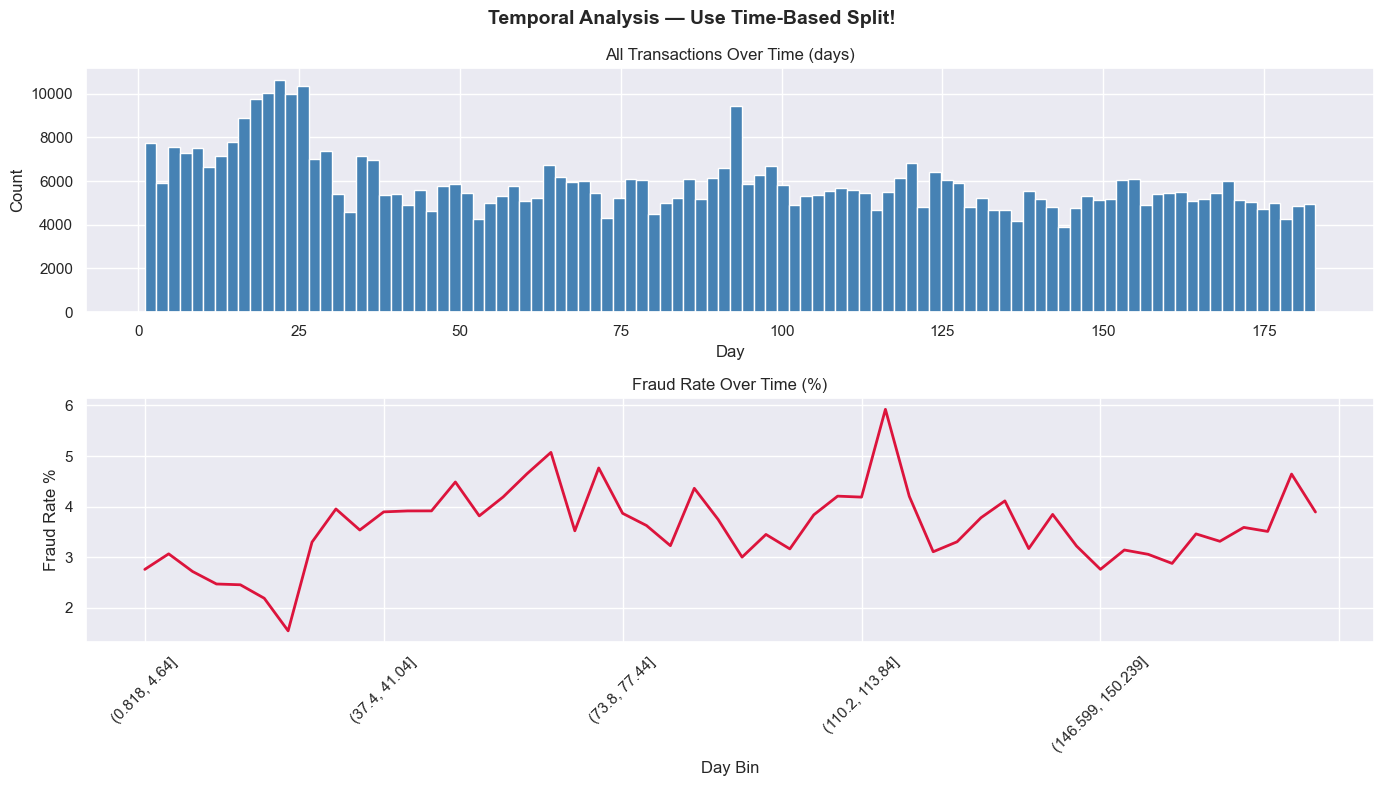


IMPORTANT: Use day 141.1 as train/val split point
   Train: days 0 → 141.1
   Val  : days 141.1 → 183.0


In [29]:
df['transaction_day'] = df['TransactionDT'] / (3600 * 24)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# All transactions over time
axes[0].hist(df['transaction_day'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('All Transactions Over Time (days)')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Count')

# Fraud rate over time (daily)
df['day_bin'] = pd.cut(df['transaction_day'], bins=50)
fraud_rate_time = df.groupby('day_bin')['isFraud'].mean() * 100
fraud_rate_time.plot(ax=axes[1], color='crimson', linewidth=2)
axes[1].set_title('Fraud Rate Over Time (%)')
axes[1].set_xlabel('Day Bin')
axes[1].set_ylabel('Fraud Rate %')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Temporal Analysis — Use Time-Based Split!',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/04_time_analysis.png', dpi=150)
plt.show()

split_day = df['transaction_day'].quantile(0.8)
print(f"\nIMPORTANT: Use day {split_day:.1f} as train/val split point")
print(f"   Train: days 0 → {split_day:.1f}")
print(f"   Val  : days {split_day:.1f} → {df['transaction_day'].max():.1f}")


In [38]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print(categorical_cols)

Index(['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1',
       'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15',
       'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33',
       'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo',
       'day_bin'],
      dtype='object')


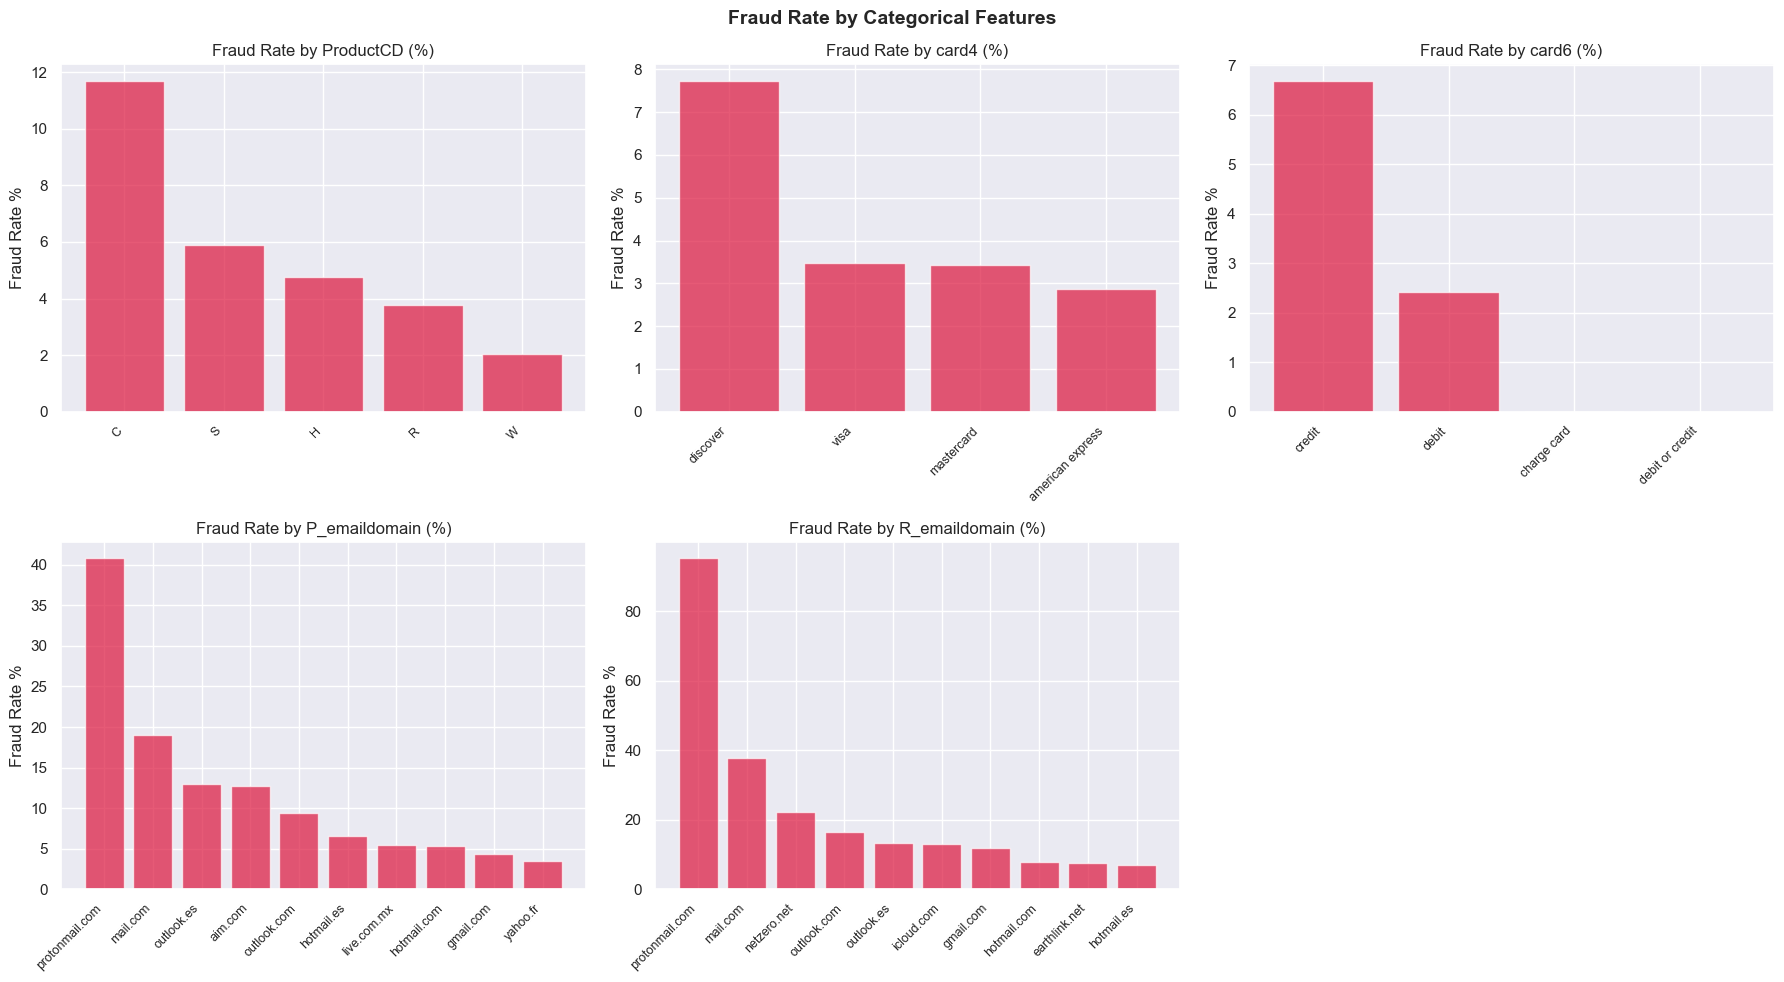

Saved: 05_categorical_fraud_rate.png


In [40]:
cat_cols = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    if col not in df.columns:
        continue
    fraud_rate = df.groupby(col)['isFraud'].mean().sort_values(ascending=False) * 100
    top = fraud_rate.head(10)
    bars = axes[i].bar(range(len(top)), top.values, color='crimson', alpha=0.7)
    axes[i].set_xticks(range(len(top)))
    axes[i].set_xticklabels(top.index, rotation=45, ha='right', fontsize=9)
    axes[i].set_title(f'Fraud Rate by {col} (%)')
    axes[i].set_ylabel('Fraud Rate %')

axes[-1].axis('off')
plt.suptitle('Fraud Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/05_categorical_fraud_rate.png', dpi=150)
plt.show()
print("Saved: 05_categorical_fraud_rate.png")

In [43]:
print("\n--- ProductCD Fraud Rates ---")
print(df.groupby('ProductCD')['isFraud'].agg(['mean', 'count'])
        .rename(columns={'mean': 'fraud_rate', 'count': 'total'})
        .assign(fraud_rate=lambda x: (x['fraud_rate'] * 100).round(2))
        .sort_values('fraud_rate', ascending=False))

print("\n--- Card Type Fraud Rates ---")
if 'card4' in df.columns:
    print(df.groupby('card4')['isFraud'].agg(['mean', 'count'])
            .rename(columns={'mean': 'fraud_rate', 'count': 'total'})
            .assign(fraud_rate=lambda x: (x['fraud_rate'] * 100).round(2))
            .sort_values('fraud_rate', ascending=False))


--- ProductCD Fraud Rates ---
           fraud_rate   total
ProductCD                    
C               11.69   68519
S                5.90   11628
H                4.77   33024
R                3.78   37699
W                2.04  439670

--- Card Type Fraud Rates ---
                  fraud_rate   total
card4                               
discover                7.73    6651
visa                    3.48  384767
mastercard              3.43  189217
american express        2.87    8328


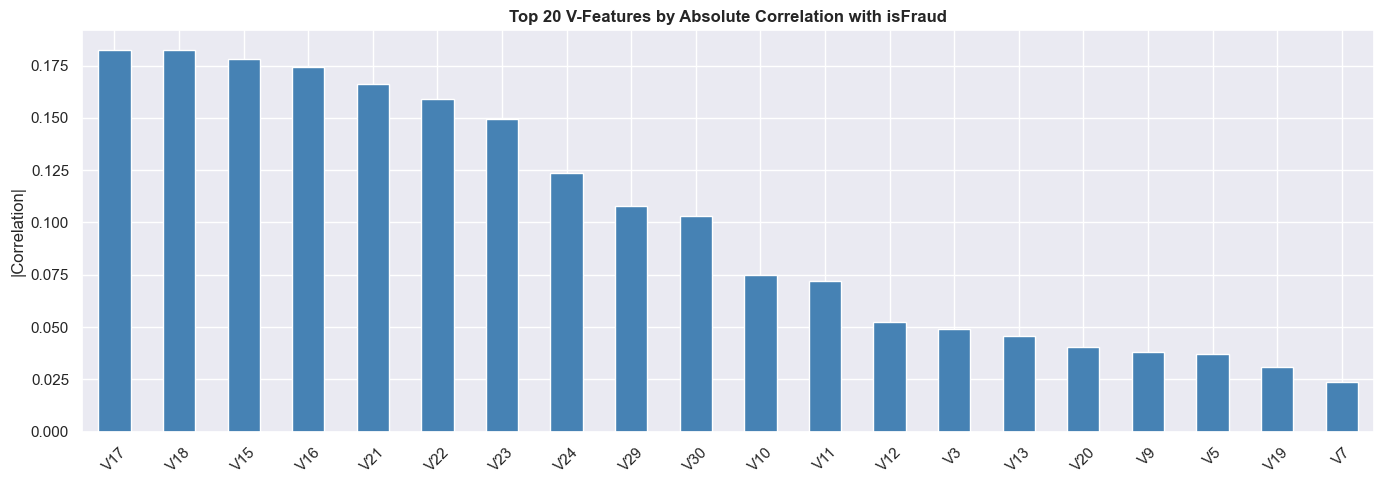

Saved: 06_v_features_correlation.png


In [44]:
# Sample 30 V features to check correlation with target
v_cols = [c for c in df.columns if c.startswith('V')][:30]
v_corr = df[v_cols + ['isFraud']].corr()['isFraud'].drop('isFraud')
v_corr_sorted = v_corr.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
v_corr_sorted.head(20).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 20 V-Features by Absolute Correlation with isFraud',
             fontweight='bold')
ax.set_ylabel('|Correlation|')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../data/processed/06_v_features_correlation.png', dpi=150)
plt.show()
print("Saved: 06_v_features_correlation.png")

In [45]:
summary = {
    'total_rows': len(df),
    'fraud_count': int(df['isFraud'].sum()),
    'fraud_rate_pct': round(df['isFraud'].mean() * 100, 2),
    'total_features': df.shape[1],
    'missing_cols': len(missing_df),
    'train_val_split_day': round(split_day, 1)
}

In [48]:
summary

{'total_rows': 590540,
 'fraud_count': 20663,
 'fraud_rate_pct': np.float64(3.5),
 'total_features': 437,
 'missing_cols': 414,
 'train_val_split_day': np.float64(141.1)}

In [47]:
import json
with open('../data/processed/eda_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("EDA summary saved to: data/processed/eda_summary.json")
print("All charts saved to:  data/processed/")

EDA summary saved to: data/processed/eda_summary.json
All charts saved to:  data/processed/
